<a href="https://colab.research.google.com/github/Jholman22/ProcesamientoImagenes2025/blob/main/APP_ORIGINAL_GREEN_MACHINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GREEN  MACHINE



Green Machine es un proyecto de visión por computador que busca identificar plantas medicinales locales como rúda, sábila, menta, coca y cimarrón a partir de una imagen. Usando YOLOv8 para clasificación y datos anotados en Roboflow, se entrenó un modelo eficiente capaz de reconocer especies con alta precisión desde la cámara del usuario.

El sistema se implementa en Google Colab y permite tomar fotos en tiempo real, clasificarlas y mostrar la predicción visualmente. Su objetivo es facilitar el reconocimiento de plantas con fines educativos, ambientales o de salud, con miras a integrar el modelo en aplicaciones móviles o de campo.

CLASES: [Sabila, Manzanilla, Cimarron, Coca, Hierbabuena, NoMedicinal,Ruda, Valeriana]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


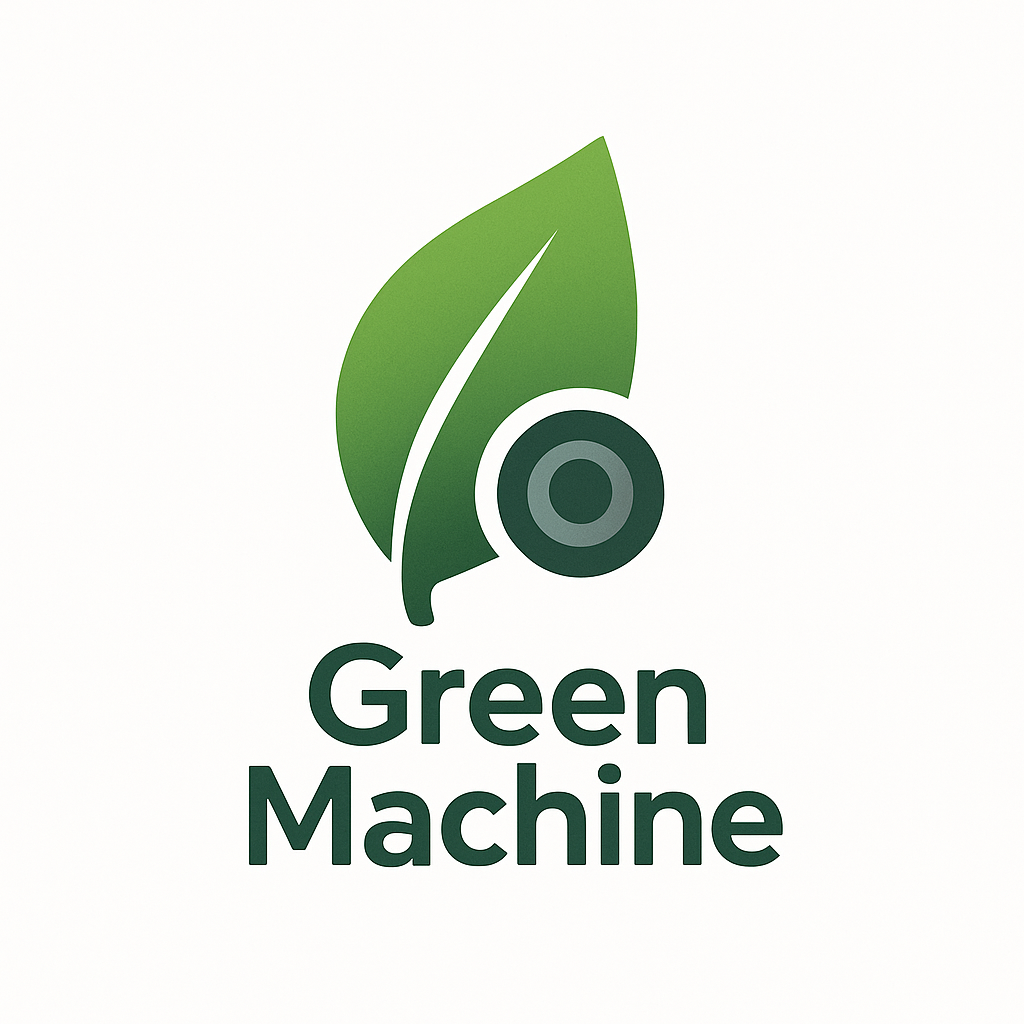

In [ ]:

from IPython.display import Image
Image("/content/drive/MyDrive/Imagenes_Procesamiento/logo_green.png", width=600)


##Instalar YoloV8



In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()


Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.2/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

##Cargar Dataset de Roboflow


In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets


!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="dk51AFjSWjBjMwGA0ybh")
project = rf.workspace("jmezapp").project("green_machine")
version = project.version(1)
dataset = version.download("folder")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# Paso 5: Verifica si data.yaml existe
print("Ubicación del dataset:", dataset.location)
!ls {dataset.location}

Ubicación del dataset: /content/datasets/Green_Machine-1
README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
print(dataset.location)

/content/datasets/Green_Machine-1


##Entrenamos el modelo YOLOV8s con nuestro dataset



Datos y procesamiento del modelo  
El modelo fue entrenado con un total de 2325 imágenes, las cuales fueron procesadas y divididas de la siguiente manera:

1. División del Conjunto de Datos

  Entrenamiento: 2034 imágenes (87%)

  Validación: 194 imágenes (8%)

  Prueba: 97 imágenes (4%)

2. Preprocesamiento
  A todas las imágenes se les aplicaron los siguientes pasos:

  Corrección automática de orientación (Auto-Orient).

  Redimensionamiento forzado (Stretch) a un tamaño de 640x640 píxeles.

3. Aumentación de Datos
Se aplicó exclusivamente al conjunto de entrenamiento, generando 3 imágenes por cada original para mejorar la robustez del modelo. Las técnicas incluyeron:

  Volteos (horizontal y vertical)

  Rotaciones (de 90° y en rangos de ±20°)

  Recorte (zoom hasta 25%)

  Cizallamiento (Shear)

  Ajustes de brillo, desenfoque y ruido

In [ ]:
%cd {HOME}

!yolo task=classify mode=train model=yolov8s-cls.pt data={dataset.location} epochs=10 imgsz=600 batch=32 plots=True


/content
New https://pypi.org/project/ultralytics/8.3.159 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=classify, mode=train, model=yolov8s-cls.pt, data=/content/datasets/Green_Machine-1, epochs=10, time=None, patience=100, batch=32, imgsz=600, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=

/content


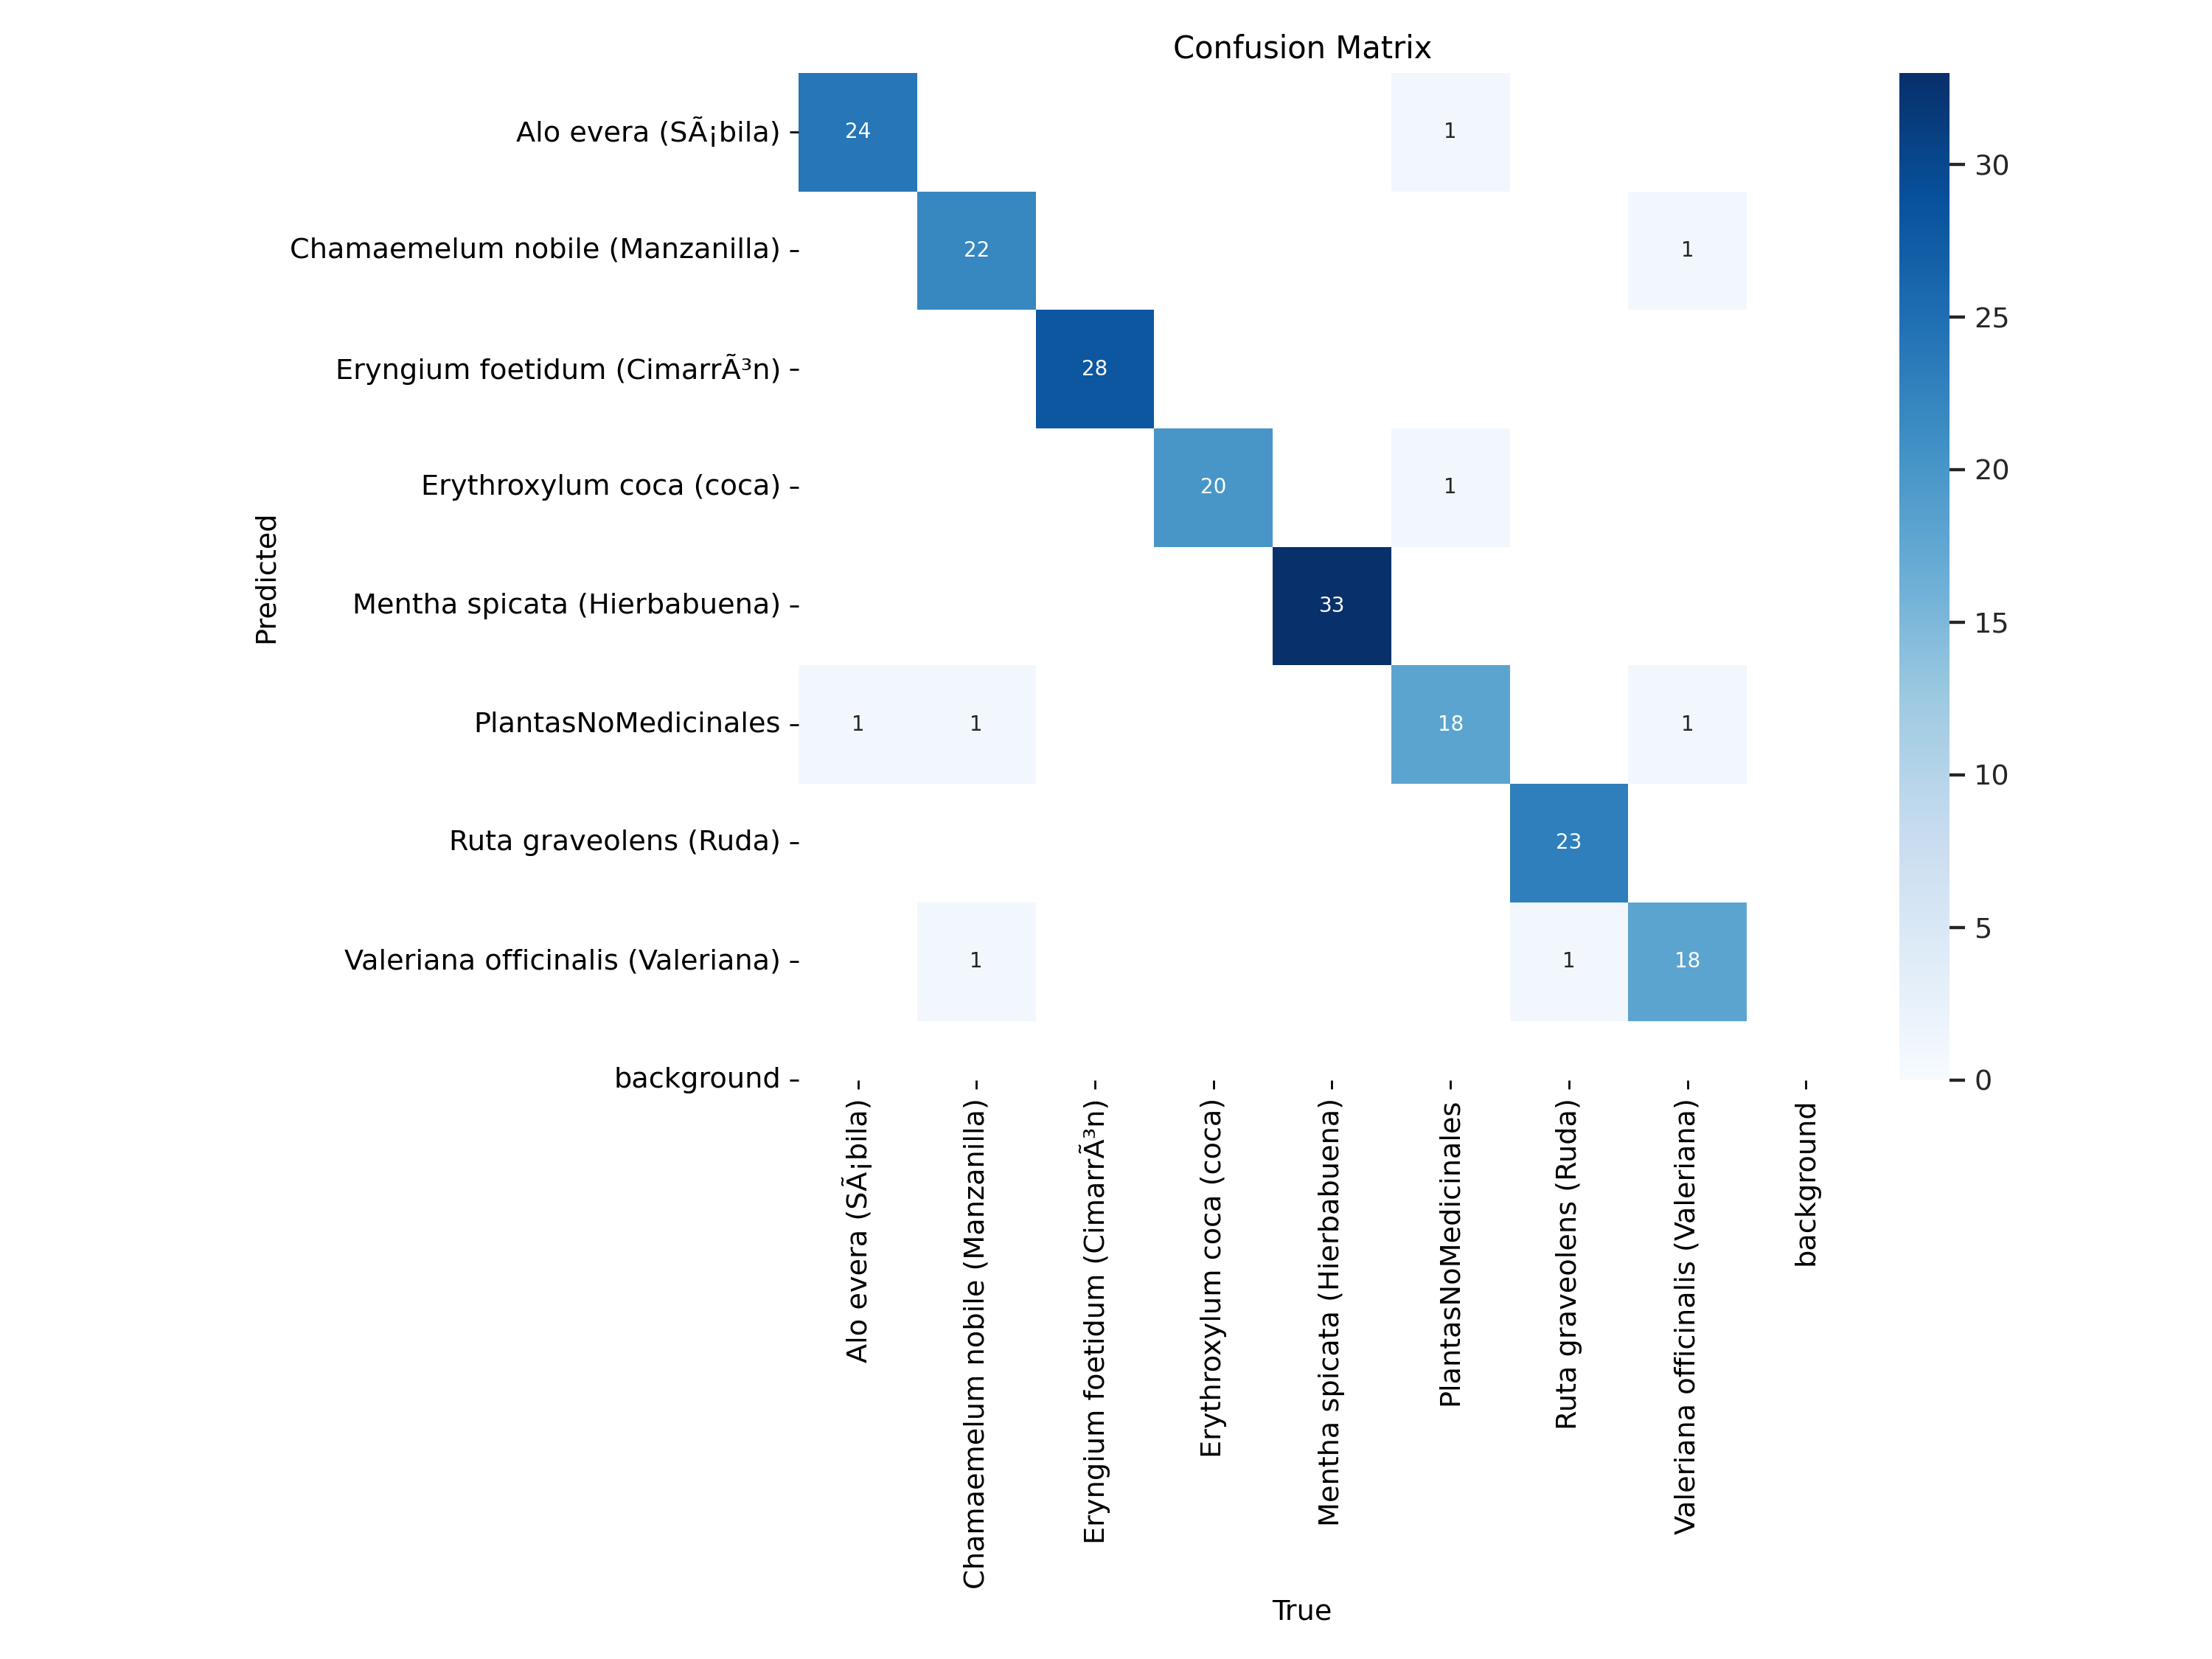

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/train2/confusion_matrix.png', width=600)


/content


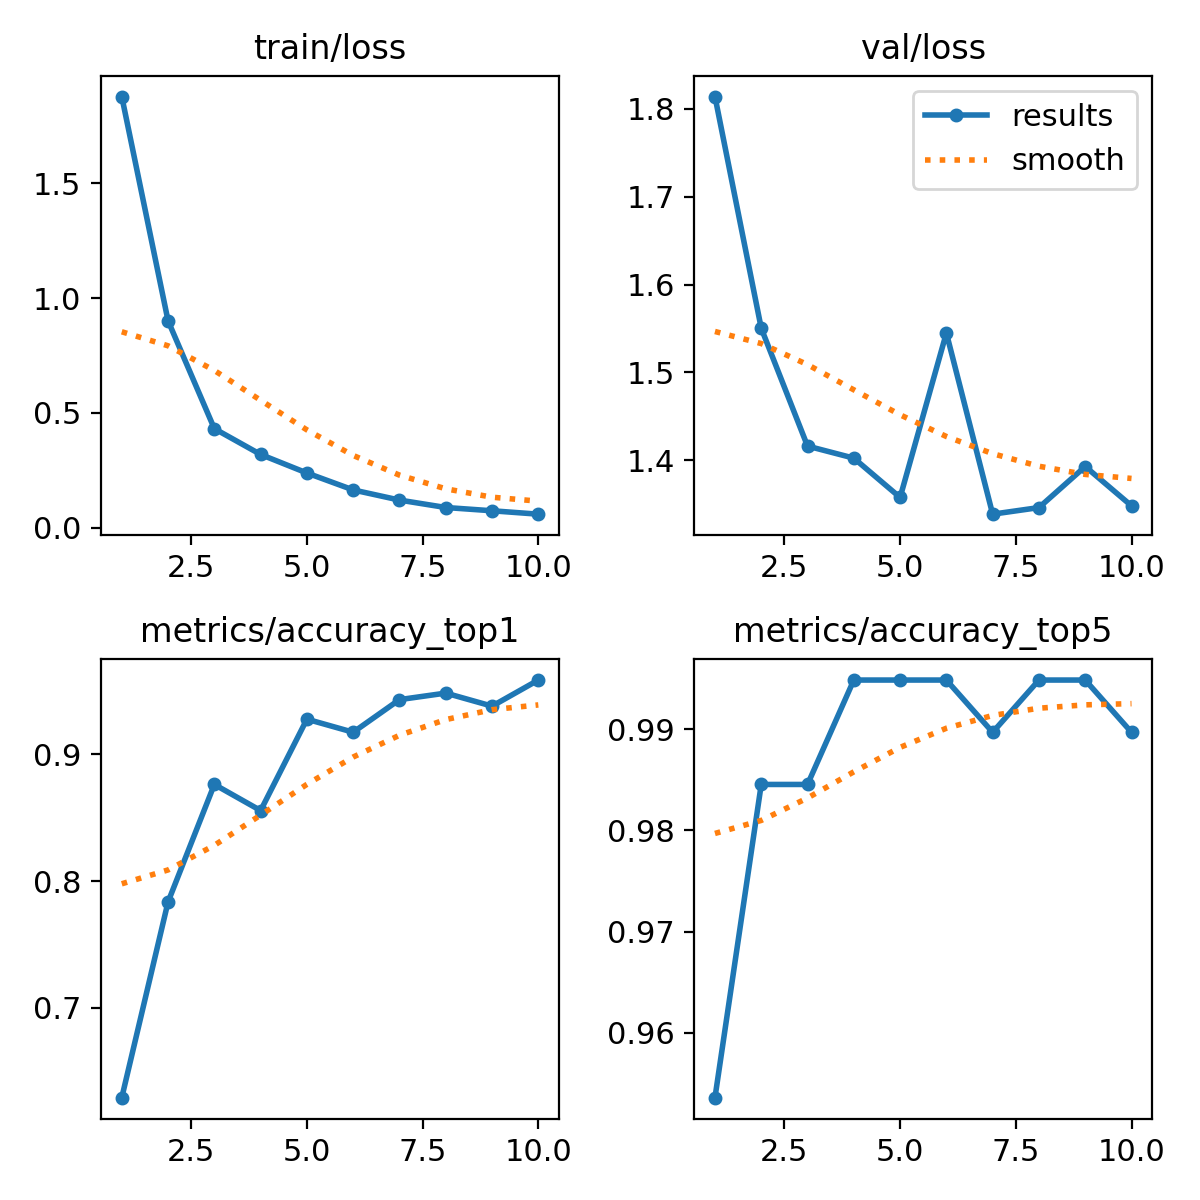

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/train2/results.png', width=600)


/content


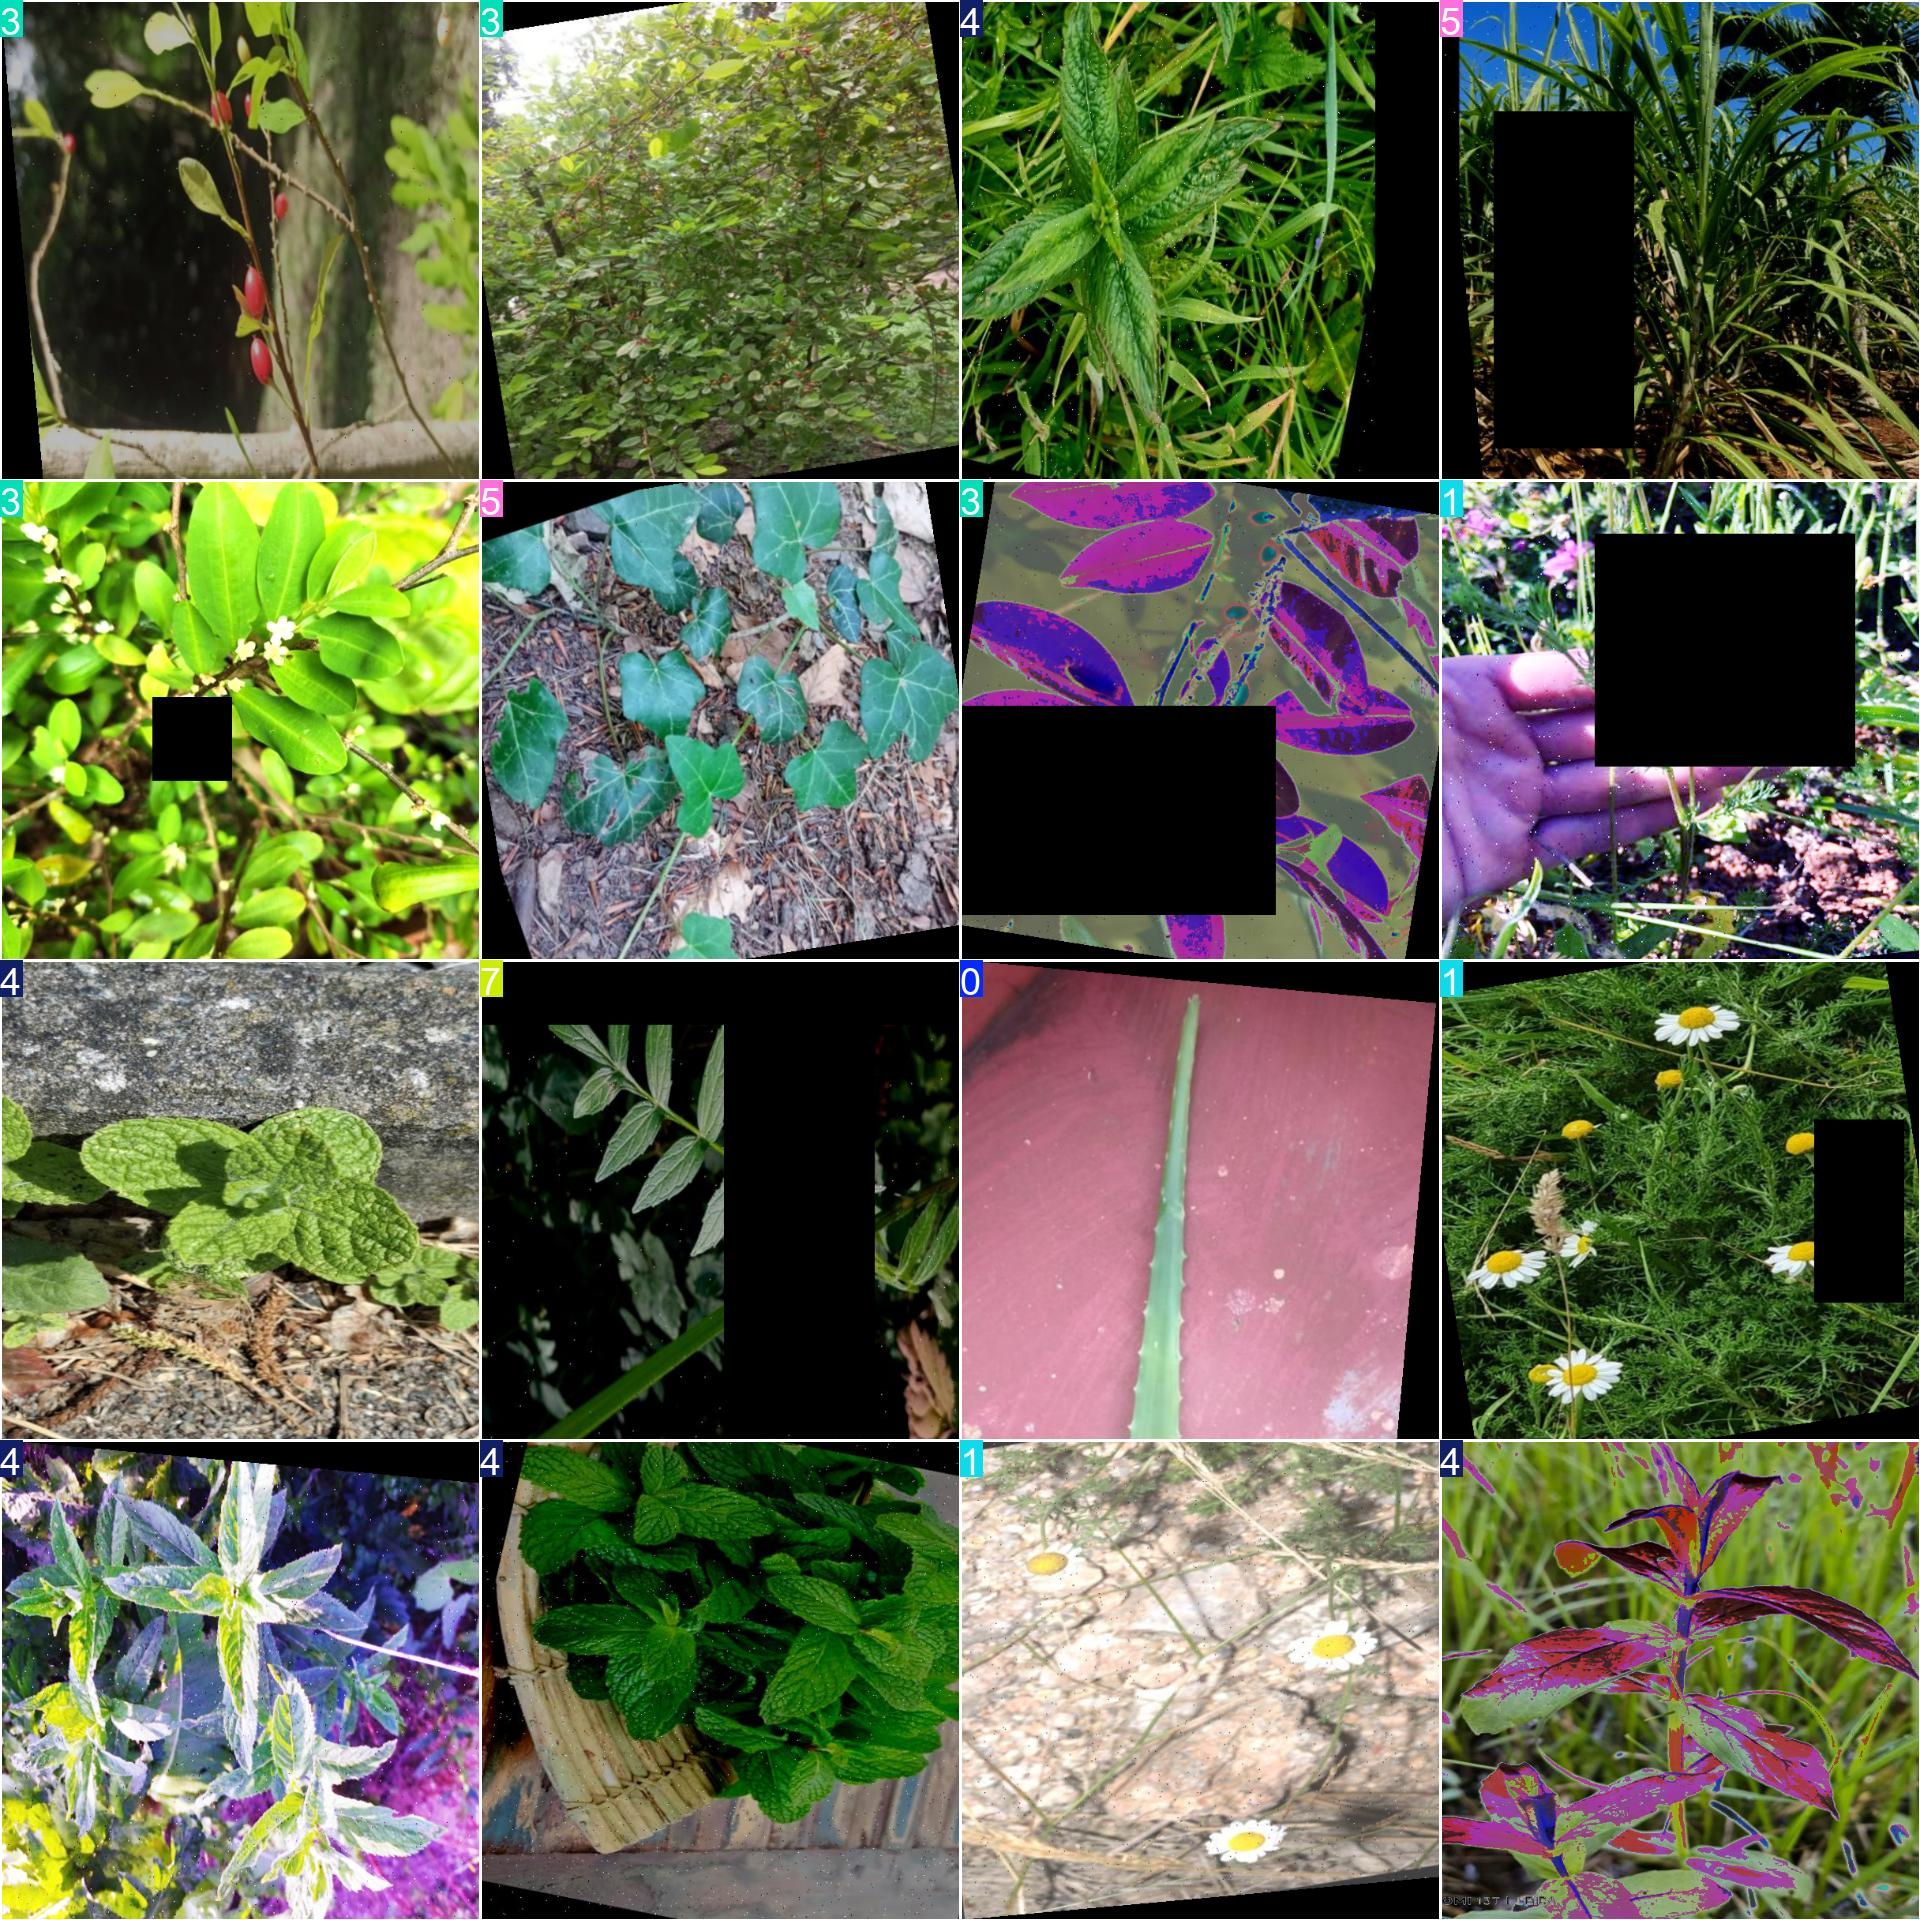

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/train/train_batch360.jpg', width=600)


In [ ]:
data_yaml = """
train: /content/datasets/Green_Machine-1/train
val: /content/datasets/Green_Machine-1/valid
test: /content/datasets/Green_Machine-1/test

nc: 8
names: ['Sabila','Manzanilla', 'Cimarron', 'Coca', 'Hierbabuena', 'NoMedicinal','Ruda', 'Valeriana']
"""

with open('/content/datasets/Green_Machine-1/data.yaml', 'w') as f:
    f.write(data_yaml)

##Validacion

In [ ]:
%cd {HOME}
!yolo task=classify mode=val model={HOME}/runs/classify/train2/weights/best.pt data={dataset.location}


/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 73 layers, 5,085,448 parameters, 0 gradients, 12.5 GFLOPs
train: /content/datasets/Green_Machine-1/train... found 2034 images in 8 classes ✅ 
val: /content/datasets/Green_Machine-1/val... found 194 images in 8 classes ✅ 
test: /content/datasets/Green_Machine-1/test... found 97 images in 8 classes ✅ 
val: Scanning /content/datasets/Green_Machine-1/val... 194 images, 0 corrupt: 100% 194/194 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100% 13/13 [00:04<00:00,  3.13it/s]
                   all      0.959       0.99
Speed: 3.8ms preprocess, 6.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val
💡 Learn more at https://docs.ultralytics.com/modes/val


/content


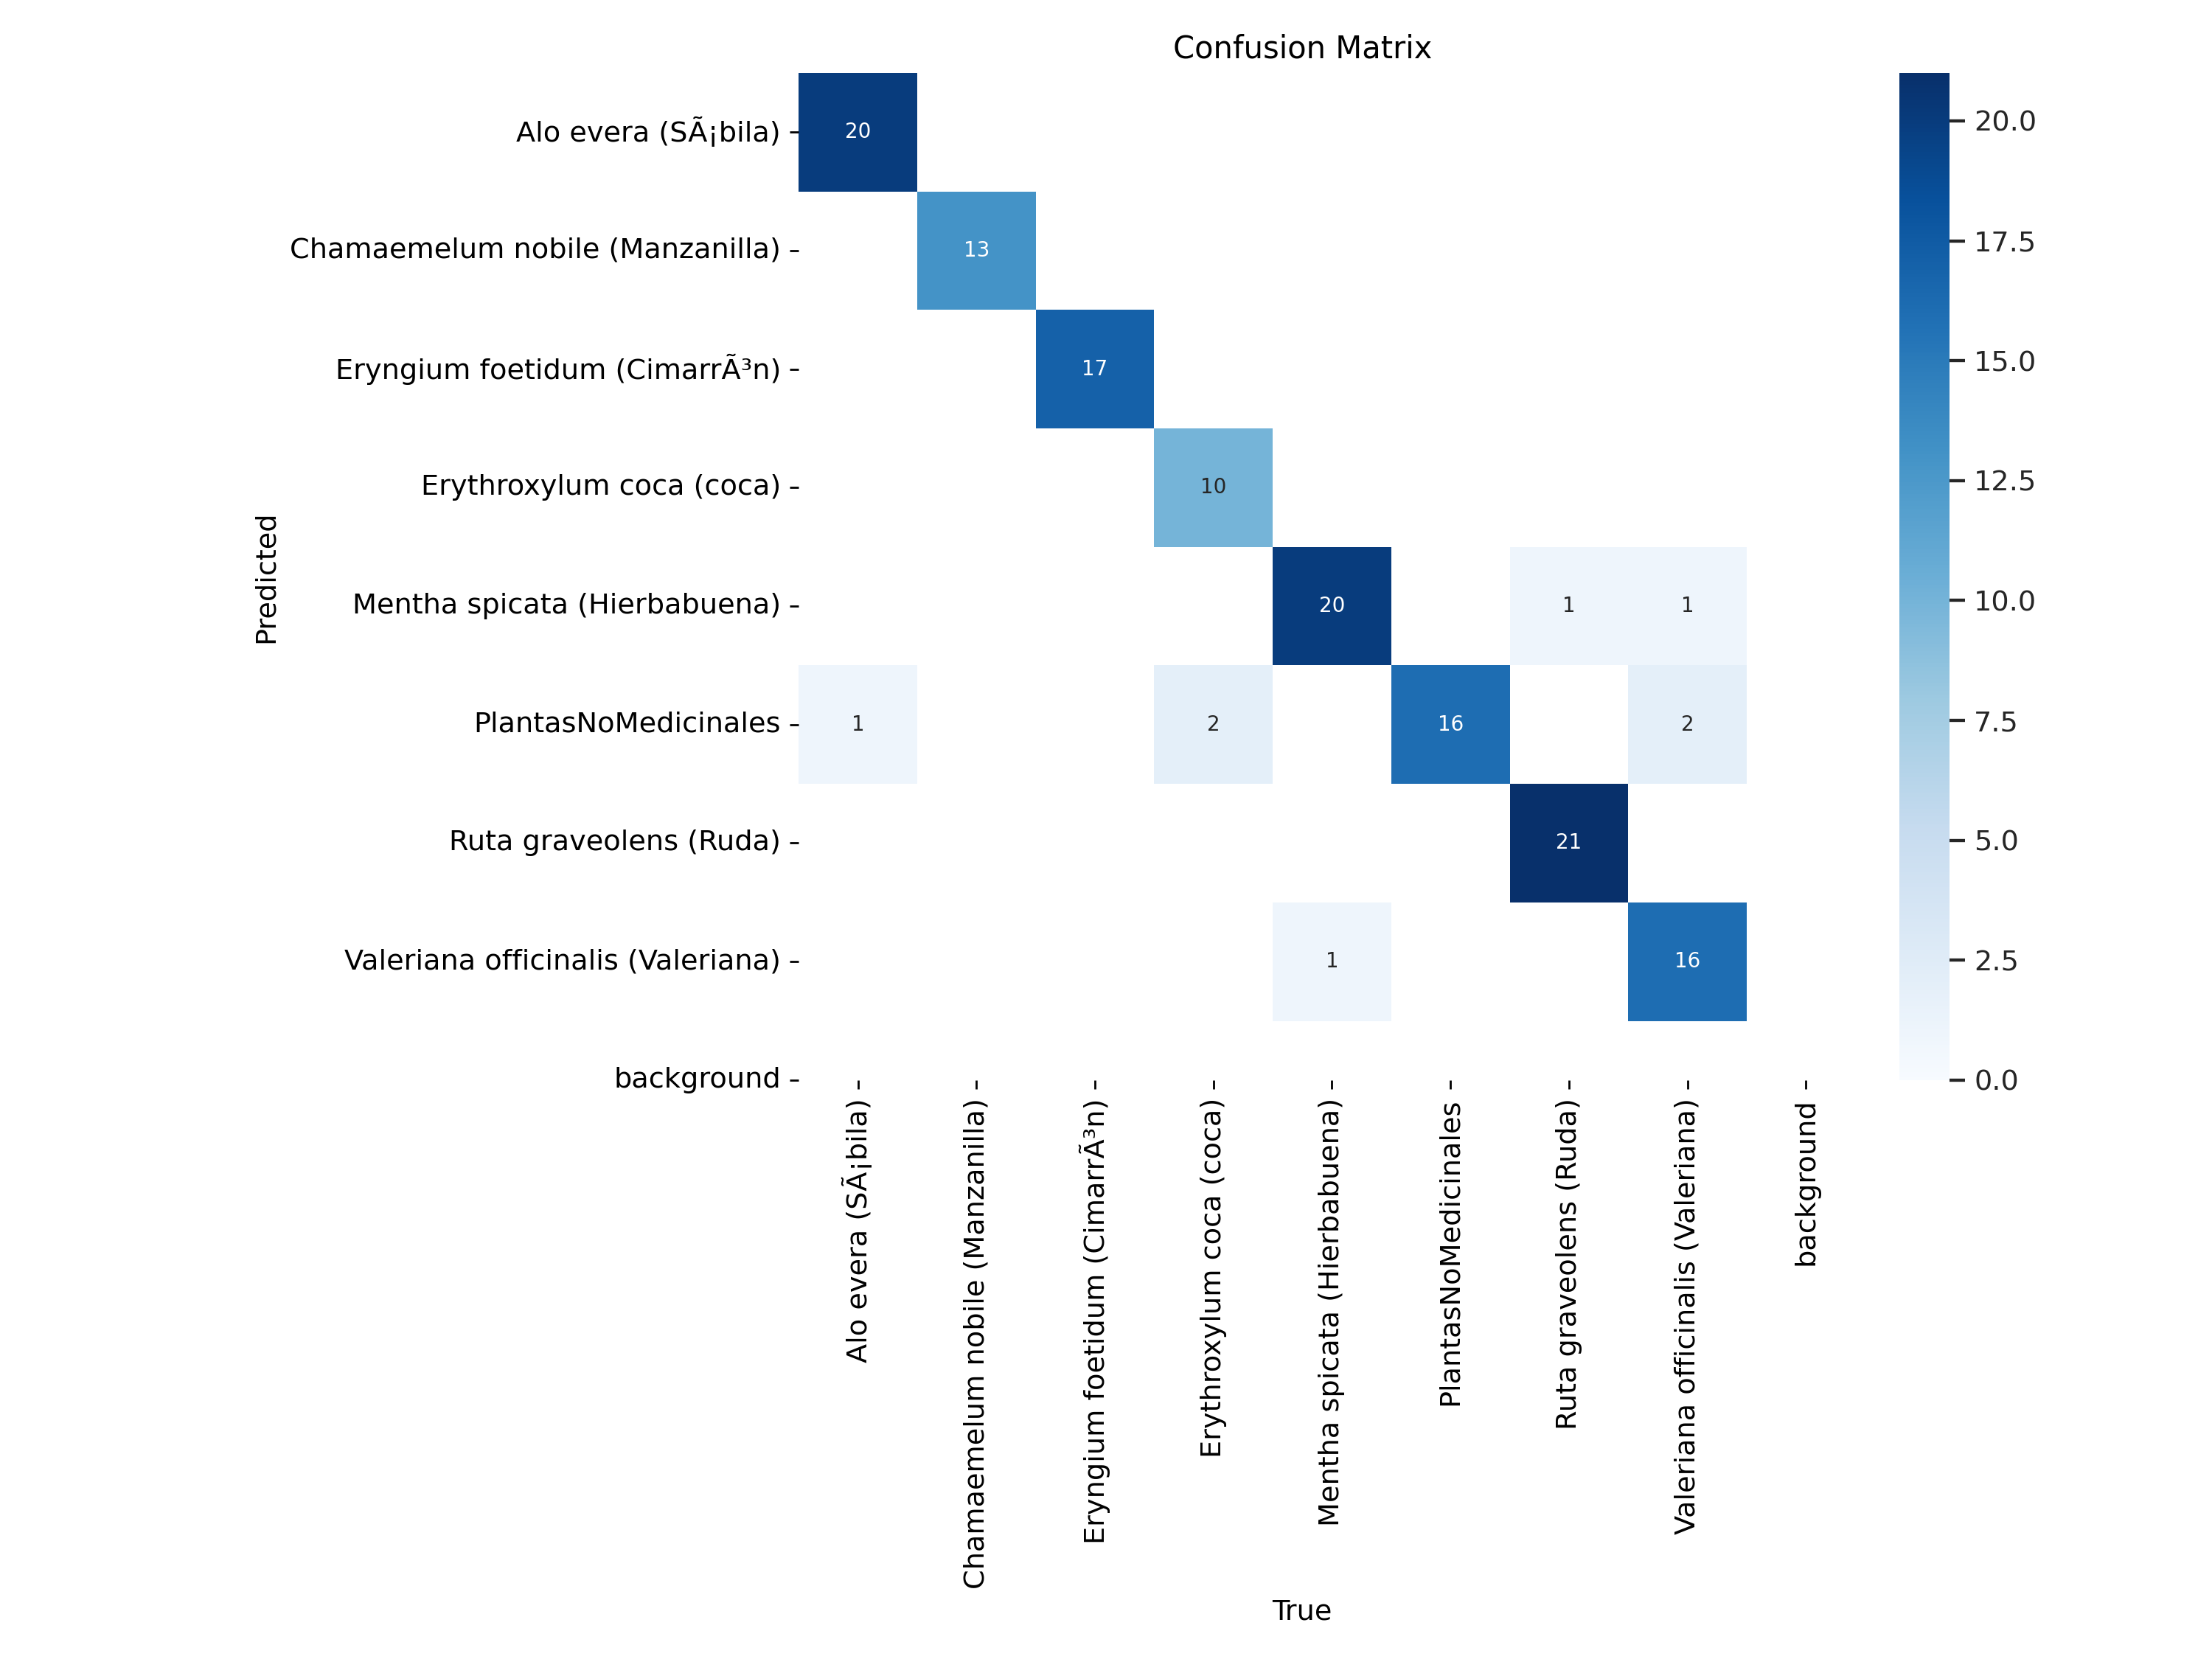

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/val2/confusion_matrix.png', width=600)


##Probando el modelo imagenes de tes


In [ ]:
# Ejemplo para una sola imagen
!yolo task=classify mode=predict model="runs/classify/train2/weights/best.pt" source="/content/datasets/Green_Machine-1/test/Mentha spicata (Hierbabuena)"

Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 73 layers, 5,085,448 parameters, 0 gradients, 12.5 GFLOPs

image 1/19 /content/datasets/Green_Machine-1/test/Mentha spicata (Hierbabuena)/hierba-buena-plantada-en-maceta_jpg.rf.a5725f80530d4514980d9555e28d873e.jpg: 608x608 Mentha spicata (Hierbabuena) 0.84, PlantasNoMedicinales 0.06, Valeriana officinalis (Valeriana) 0.06, Erythroxylum coca (coca) 0.02, Alo evera (SÃ¡bila) 0.01, 7.5ms
image 2/19 /content/datasets/Green_Machine-1/test/Mentha spicata (Hierbabuena)/img_102_jpg.rf.d4388f247a008dbf1618049a71ea7a0f.jpg: 608x608 Mentha spicata (Hierbabuena) 1.00, Valeriana officinalis (Valeriana) 0.00, PlantasNoMedicinales 0.00, Chamaemelum nobile (Manzanilla) 0.00, Ruta graveolens (Ruda) 0.00, 7.5ms
image 3/19 /content/datasets/Green_Machine-1/test/Mentha spicata (Hierbabuena)/img_105_jpg.rf.6c479da880ea65dc22c9cb8a499cc8e1.jpg: 608x608 Mentha spicata (Hierbabuena) 1.00, Valer

##Probando el modelo con camara


In [ ]:
model = YOLO("runs/classify/train2/weights/best.pt")

# Asigna los nombres de clase en el orden correcto (según carpetas de tu dataset)
model.model.names = ['Sabila','Manzanilla', 'Cimarron', 'Coca', 'Hierbabuena', 'NoMedicinal','Ruda', 'Valeriana']  # ejemplo



In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image
import io
import cv2
import numpy as np

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image
import io
import cv2
import numpy as np
from matplotlib import pyplot as plt
from ultralytics import YOLO



In [ ]:
model = YOLO("runs/classify/train2/weights/best.pt")
# Asigna los nombres de clase en el orden correcto (según carpetas de tu dataset)
model.model.names = ['Sabila','Manzanilla', 'Cimarron', 'Coca', 'Hierbabuena', 'NoMedicinal','Ruda', 'Valeriana']  # ejemplo

info_plantas = {
    'Sabila': 'Aloe vera. Usos: cicatrizante, hidratante, digestivo.',
    'Manzanilla': 'Matricaria chamomilla. Usos: calmante, digestiva.',
    'Cimarron': 'Eryngium foetidum. Usos: condimento, antiinflamatorio.',
    'Coca': 'Erythroxylum coca. Usos: ancestral, energizante, digestiva.',
    'Hierbabuena': 'Mentha spicata. Usos: digestiva, antiséptica.',
    'NoMedicinal': 'Sin uso medicinal conocido.',
    'Ruda': 'Ruta graveolens. Usos: cólicos, regulación menstrual.',
    'Valeriana': 'Valeriana officinalis. Usos: ansiedad, insomnio.'
}

info_plantas = {
    'Sabila': {
        'nombre_comun': 'Sábila o Aloe Vera',
        'nombre_cientifico': 'Aloe vera',
        'familia': 'Asphodelaceae',
        'descripcion': 'Planta suculenta con hojas carnosas y alargadas que contienen un gel transparente en su interior, muy apreciado por sus propiedades medicinales y cosméticas.',
        'usos_medicinales': [
            'Tratamiento de quemaduras solares y heridas leves.',
            'Hidratación profunda de la piel y el cabello.',
            'Alivio del estreñimiento (consumo del jugo).',
            'Cuidado post-afeitado o post-depilación.'
        ],
        'propiedades': ['Cicatrizante', 'Antiinflamatorio', 'Hidratante', 'Laxante suave'],
        'preparacion': 'Uso tópico del gel extraído directamente de la hoja. Consumo del jugo procesado.',
        'precauciones': 'El consumo interno debe ser moderado. La capa amarilla bajo la corteza (aloína) puede ser irritante y laxante fuerte; se recomienda retirarla.'
    },
    'Cimarron': {
        'nombre_comun': 'Cimarrón o Culantro',
        'nombre_cientifico': 'Eryngium foetidum',
        'familia': 'Apiaceae',
        'descripcion': 'Hierba aromática con hojas largas y dentadas. Su olor y sabor son similares al cilantro, pero mucho más intensos. Muy usado en la gastronomía caribeña y asiática.',
        'usos_medicinales': [
            'Alivio de dolores estomacales y gases.',
            'Tratamiento de la fiebre y el resfriado.',
            'Estímulo del apetito.'
        ],
        'propiedades': ['Digestivo', 'Carminativo (antigases)', 'Antiinflamatorio', 'Febrífugo'],
        'preparacion': 'Infusión de las hojas. Uso de las hojas frescas o secas como condimento.',
        'precauciones': 'Seguro en cantidades culinarias. En dosis medicinales, consultar a un especialista.'
    },
    'Coca': {
        'nombre_comun': 'Hoja de Coca',
        'nombre_cientifico': 'Erythroxylum coca',
        'familia': 'Erythroxylaceae',
        'descripcion': 'Arbusto originario de los Andes, con un profundo significado cultural y religioso para las comunidades indígenas. Sus hojas son conocidas por sus propiedades estimulantes.',
        'usos_medicinales': [
            'Combatir el mal de altura ("soroche").',
            'Aumentar la energía y reducir la sensación de hambre.',
            'Alivio de dolores de cabeza y malestares digestivos.'
        ],
        'propiedades': ['Energizante', 'Estimulante suave', 'Digestivo', 'Analgésico local'],
        'preparacion': 'Masticado de las hojas (acullico) o en infusión (mate de coca).',
        'precauciones': 'Planta controlada en muchos países debido a su alcaloide. Su uso tradicional es legal y aceptado en países como Bolivia y Perú, pero su exportación y posesión pueden ser ilegales en otros lugares.'
    },
    'Hierbabuena': {
        'nombre_comun': 'Hierbabuena o Menta Verde',
        'nombre_cientifico': 'Mentha spicata',
        'familia': 'Lamiaceae',
        'descripcion': 'Planta aromática muy popular, con hojas lanceoladas y un aroma fresco y penetrante. Es un híbrido natural entre diferentes especies de menta.',
        'usos_medicinales': [
            'Alivio de la indigestión, náuseas y cólicos.',
            'Descongestionante para las vías respiratorias.',
            'Propiedades antisépticas para el mal aliento.'
        ],
        'propiedades': ['Digestiva', 'Antiespasmódica', 'Carminativa', 'Antiséptica'],
        'preparacion': 'Infusión de las hojas frescas o secas. Masticado de las hojas.',
        'precauciones': 'Evitar su consumo en grandes cantidades durante el embarazo y la lactancia.'
    },
    'Ruda': {
        'nombre_comun': 'Ruda',
        'nombre_cientifico': 'Ruta graveolens',
        'familia': 'Rutaceae',
        'descripcion': 'Arbusto de olor fuerte y característico, con hojas de color verde azulado. Ha sido utilizada desde la antigüedad en rituales y como planta medicinal.',
        'usos_medicinales': [
            'Alivio de cólicos y dolores menstruales.',
            'Tratamiento de espasmos y dolores de cabeza.',
            'Tradicionalmente usada como amuleto de protección.'
        ],
        'propiedades': ['Antiespasmódica', 'Emenagoga (regula la menstruación)', 'Sedante'],
        'preparacion': 'Infusión de las hojas en muy pequeñas cantidades.',
        'precauciones': 'Planta tóxica en dosis altas. Es abortiva, por lo que está estrictamente prohibida en el embarazo. Puede causar irritación en la piel (fotosensibilidad).'
    },
    'Valeriana': {
        'nombre_comun': 'Valeriana',
        'nombre_cientifico': 'Valeriana officinalis',
        'familia': 'Caprifoliaceae',
        'descripcion': 'Planta herbácea cuyas raíces son famosas por sus efectos relajantes sobre el sistema nervioso central. Es uno de los remedios naturales más populares para el insomnio.',
        'usos_medicinales': [
            'Tratamiento del insomnio y problemas para dormir.',
            'Reducción de la ansiedad, el estrés y el nerviosismo.',
            'Alivio de la agitación y la irritabilidad.'
        ],
        'propiedades': ['Sedante', 'Relajante', 'Ansiolítico', 'Hipotensora suave'],
        'preparacion': 'Infusión de la raíz seca, extractos, cápsulas o tinturas.',
        'precauciones': 'Puede causar somnolencia, no se debe conducir ni operar maquinaria pesada tras su consumo. No combinar con alcohol u otros sedantes.'
    },
    'NoMedicinal': {
        'nombre_comun': 'No Medicinal',
        'nombre_cientifico': 'N/A',
        'familia': 'N/A',
        'descripcion': 'Esta categoría se usa para plantas que no han sido identificadas como medicinales en el contexto de este proyecto.',
        'usos_medicinales': ['Ninguno conocido.'],
        'propiedades': ['Ninguna.'],
        'preparacion': 'No aplica.',
        'precauciones': 'No se recomienda su consumo.'
    }
}


In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 Tomar Foto';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Espera a que se presione el botón
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


In [ ]:
def clasificar_con_camara():
    print("🎥 Abriendo cámara...")
    photo_path = take_photo()
    print(f"📸 Foto guardada en: {photo_path}")

    # Predicción
    results = model(photo_path)
    r = results[0]

    # Obtener clase predicha
    top_idx = r.probs.top1
    label = model.model.names[top_idx]
    conf = r.probs.data[top_idx].item()

    # Información adicional
    info = info_plantas.get(label, "Información no disponible.")

    # Mostrar resultado
    print(f"\n🌿 Clase predicha: {label} ({conf:.2f})")
    print(f"📚 Información: {info}")

    # Mostrar en la imagen
    image = cv2.imread(photo_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    cv2.putText(image, f'{label} ({conf:.2f})', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"{label} ({conf:.2f})")
    plt.show()


🎥 Abriendo cámara...


<IPython.core.display.Javascript object>

📸 Foto guardada en: photo.jpg

image 1/1 /content/photo.jpg: 608x608 Ruda 0.89, Manzanilla 0.03, NoMedicinal 0.02, Valeriana 0.02, Coca 0.01, 7.7ms
Speed: 22.2ms preprocess, 7.7ms inference, 0.1ms postprocess per image at shape (1, 3, 608, 608)

🌿 Clase predicha: Ruda (0.89)
📚 Información: Ruta graveolens. Usos: cólicos, regulación menstrual.


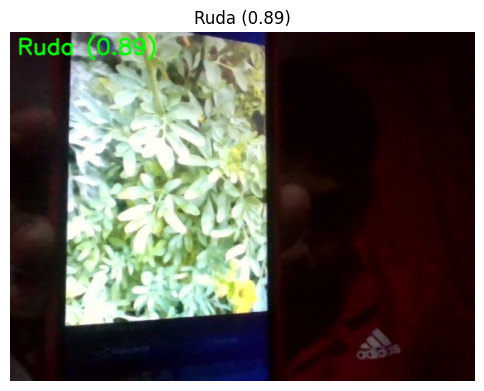

In [ ]:
clasificar_con_camara()